In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import bioframe
import cooltools
import pandas as pd

from ggner_3d.saddle import pq_saddle, saddle_mp
import cooltools
from ggner_3d.cm import CLR_CONNS, prepare_view_df, get_expected_trans_df, get_eig_data
import cooler

resolution = 100_000
NPROC = 8
max_diag_large = int(10_000_000 // resolution)
max_diag_small = int(1_000_000 // resolution)
n_bins = 50
qrange = (0.05, 0.95)
cell_type = 'u2os' # u2os, pol2, hela
save_dir = '/home/carlos/Clone/ggner-3d/figs/saddle_trans_pq_same_arm'

### libs

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def _to_matrix(x):
    """
    Normalize different saddle outputs to a plain matrix.
    - cooltools.saddle output after sc2saddle: already ndarray
    - cooltools.saddle raw output: (sum, count)
    - pq_saddle output: dict with key 'saddle'
    """
    if isinstance(x, dict):
        return x["saddle"]
    if isinstance(x, tuple) and len(x) == 2:
        s, c = x
        out = s / c
        out[c == 0] = np.nan
        return out
    return x


def _log2_matrix(mtx):
    out = np.full_like(mtx, np.nan, dtype=float)
    valid = np.isfinite(mtx) & (mtx > 0)
    out[valid] = np.log2(mtx[valid])
    return out


def _log2fc_matrix(base, comp):
    out = np.full_like(base, np.nan, dtype=float)
    valid = (
        np.isfinite(base) & np.isfinite(comp) &
        (base > 0) & (comp > 0)
    )
    out[valid] = np.log2(comp[valid] / base[valid])
    return out


def _format_mb_label(bp):
    mb = bp / 1_000_000
    if float(mb).is_integer():
        return f"{int(mb)} Mb"
    return f"{mb:.1f} Mb"


def _get_limits(mtx, symmetric=True, fallback=1):
    finite = np.isfinite(mtx)
    if not finite.any():
        return -fallback, fallback

    if symmetric:
        vmax = np.nanmax(np.abs(mtx))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = fallback
        return -vmax, vmax

    vmin = np.nanmin(mtx)
    vmax = np.nanmax(mtx)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return -fallback, fallback

    if vmin == vmax:
        if vmin == 0:
            return -fallback, fallback
        eps = abs(vmin) * 0.05
        if eps == 0:
            eps = fallback
        return vmin - eps, vmax + eps

    return vmin, vmax


def plot_saddle_comparison_5x2(
    comparison,
    trans_saddles,
    pq_saddles,
    same_arm_saddles,
    same_arm_saddles_upper_bounded_large,
    same_arm_saddles_upper_bounded_small,
    upper_bound_large,
    upper_bound_small,
    figsize=(10, 22),
    cmap="vlag",
    symmetric_left=False,
    symmetric_right=True,
):
    s0, s1 = comparison

    saddle_sets = [
        ("trans", _to_matrix(trans_saddles[s0]), _to_matrix(trans_saddles[s1])),
        ("pq", _to_matrix(pq_saddles[s0]), _to_matrix(pq_saddles[s1])),
        ("same arm", _to_matrix(same_arm_saddles[s0]), _to_matrix(same_arm_saddles[s1])),
        (
            f"same arm ≤ {_format_mb_label(upper_bound_large)}",
            _to_matrix(same_arm_saddles_upper_bounded_large[s0]),
            _to_matrix(same_arm_saddles_upper_bounded_large[s1]),
        ),
        (
            f"same arm ≤ {_format_mb_label(upper_bound_small)}",
            _to_matrix(same_arm_saddles_upper_bounded_small[s0]),
            _to_matrix(same_arm_saddles_upper_bounded_small[s1]),
        ),
    ]

    fig, axs = plt.subplots(5, 2, figsize=figsize)

    for i, (row_name, m0, m1) in enumerate(saddle_sets):
        m0_log2 = _log2_matrix(m0)
        l2fc = _log2fc_matrix(m0, m1)
        mean_fc = np.nanmean(l2fc)

        vmin0, vmax0 = _get_limits(m0_log2, symmetric=symmetric_left)
        vmin1, vmax1 = _get_limits(l2fc, symmetric=symmetric_right)

        sns.heatmap(
            m0_log2,
            ax=axs[i, 0],
            cmap=cmap,
            center=0,
            vmin=vmin0,
            vmax=vmax0,
            cbar_kws={"label": f"log2 saddle ({s0})"},
            square=True,
            xticklabels=False,
        )
        axs[i, 0].set_title(f"{row_name}: {s0}")
        axs[i, 0].set_xlabel("")
        axs[i, 0].set_ylabel("")

        sns.heatmap(
            l2fc,
            ax=axs[i, 1],
            cmap=cmap,
            center=0,
            vmin=vmin1,
            vmax=vmax1,
            cbar_kws={"label": f"log2FC ({s1}/{s0})"},
            square=True,
            xticklabels=False,
        )
        axs[i, 1].set_title(
            f"{row_name}: log2({s1} / {s0})\nmean log2FC = {mean_fc:.3f}"
        )
        axs[i, 1].set_xlabel("")
        axs[i, 1].set_ylabel("")

    return fig, axs

### data prep

In [3]:
cis_WEIGHT_mapping = {
    "WTnoUV": "sweight",
    "WT1h": "sweight",
    "WT3h": "sweight",
    "WT6h": "sweight",
    "XPCnoUV": "sweight",
    "XPC3h": "sweight",
    "XPAnoUV": "sweight",
    "XPA1h": "sweight",
    "XPA3h": "sweight",
    "XPA6h": "sweight",
    "POL2_control": "weight",
    "POL2_degron": "weight",
    "WAPL_control": "weight",
    "WAPL_degron": "weight",
    "t0": "weight",
    "t12": "weight",
    "t30": "weight",
    "t60": "weight",
}

trans_WEIGHT_mapping = {
    "WTnoUV": "sweight",
    "WT1h": "sweight",
    "WT3h": "sweight",
    "WT6h": "sweight",
    "XPCnoUV": "sweight",
    "XPC3h": "sweight",
    "XPAnoUV": "sweight",
    "XPA1h": "sweight",
    "XPA3h": "sweight",
    "XPA6h": "sweight",
    "POL2_control": "weight",
    "POL2_degron": "weight",
    "WAPL_control": "weight",
    "WAPL_degron": "weight",
    "t0": "full",
    "t12": "full",
    "t30": "full",
    "t60": "full",
}

view_df_arm = prepare_view_df(arm=True)
view_df_chrom = prepare_view_df(arm=False)

if cell_type == 'u2os':

    # --- WT ---

    sample_names = ['WTnoUV', 'WT1h', 'WT3h', 'WT6h', 'XPCnoUV', 'XPC3h', 'XPAnoUV', 'XPA1h', 'XPA3h', 'XPA6h']
    comparisons = [
        ('WTnoUV', 'XPCnoUV'), ('XPCnoUV', 'XPC3h'), 
        ('WTnoUV', 'WT1h'), ('WTnoUV', 'WT3h'), ('WTnoUV', 'WT6h'),
        ('WT1h', 'WT3h'), ('WT3h', 'WT6h'),
        ('WTnoUV', 'XPAnoUV'), ('XPAnoUV', 'XPA3h'),
        ('XPAnoUV', 'XPA1h'), ('XPAnoUV', 'XPA6h')
    ]

    clr_ = CLR_CONNS(resolution)
    clr = clr_['WTnoUV']
    clr_sample_name = 'WTnoUV'
    track_name = 'wtnouvE1'
    blacklist = ['chr6', 'chr21', 'chr22']

elif cell_type == 'pol2':
    # --- POL2 ---

    sample_names = ['POL2_control', 'POL2_degron']
    comparisons = [('POL2_control', 'POL2_degron')]

    clr_ = {
        'POL2_control': cooler.Cooler(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394172_control_mergeRep_500bp.mcool::/resolutions/{resolution}'),
        'POL2_degron': cooler.Cooler(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394173_degron_mergeRep_500bp.mcool::/resolutions/{resolution}')
    }

    clr = clr_['POL2_control']
    clr_sample_name = 'POL2_control'
    track_name = 'pol2controlE1'
    blacklist = None

elif cell_type == 'hela':
    ### --- HeLa --

    clr_t0 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289939_t0_q30.mcool::/resolutions/{resolution}")
    clr_t12 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289940_t12_q30.mcool::/resolutions/{resolution}")
    clr_t30 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289941_t30_q30.mcool::/resolutions/{resolution}")
    clr_t60 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289942_t60_q30.mcool::/resolutions/{resolution}")
    clr_ = {
        't0': clr_t0,
        't12': clr_t12,
        't30': clr_t30,
        't60': clr_t60,
    }

    sample_names = ['t0', 't12', 't30', 't60']
    comparisons = [('t0', 't12'), ('t12', 't30'), ('t30', 't60'), ('t0', 't30'), ('t0', 't60')]
    clr = clr_['t0']
    clr_sample_name = 't0'
    track_name = 't0E1'
    blacklist = None

In [4]:
bins = clr.bins()[:]
hg38_genome = bioframe.load_fasta('/home/carlos/Clone/ggner-3d/hg38.fa')
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)

evals, evecs = cooltools.api.eigdecomp.eigs_cis(
    clr,
    phasing_track=gc_cov,
    view_df=view_df_chrom,
    clr_weight_name=cis_WEIGHT_mapping[clr_sample_name],
    sort_metric='MAD_explained'
)

saddle_track = evecs[['chrom', 'start', 'end', 'E1']].copy()

/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/bioframe/extras.py:316: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("chrom", sort=False)[["start", "end"]].apply(_each)
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):


In [5]:
cis_expected_ = {k: cooltools.api.expected.expected_cis(
    clr_[k],
    view_df=view_df_arm,
    clr_weight_name=cis_WEIGHT_mapping[k],
    nproc=NPROC,
    intra_only=False
) for k in sample_names}

try:
    trans_expected_ = {k: get_expected_trans_df(k, resolution_kb=resolution // 1000) for k in sample_names}
except Exception as e:
    trans_expected_ = {k: cooltools.api.expected.expected_trans(
        clr_[k],
        view_df=view_df_chrom,
        clr_weight_name=trans_WEIGHT_mapping[k],
        nproc=NPROC
    ) for k in sample_names}

expected_same_arm = {
    k: df.loc[df.region1 == df.region2].reset_index(drop=True) for k, df in cis_expected_.items()
}

expected_p_q = {
    k: df.loc[df.region1 != df.region2].reset_index(drop=True) for k, df in cis_expected_.items()
}

if blacklist is not None:
    view_df_arm = view_df_arm.loc[
        ~view_df_arm["chrom"].isin(blacklist)
    ].reset_index(drop=True)

    view_df_chrom = view_df_chrom.loc[
        ~view_df_chrom["chrom"].isin(blacklist)
    ].reset_index(drop=True)

    blacklist_pq = [f"{c}_p" for c in blacklist] + [f"{c}_q" for c in blacklist]

    expected_same_arm = {
        k: df.loc[
            ~(df.region1.isin(blacklist_pq) | df.region2.isin(blacklist_pq))
        ].reset_index(drop=True)
        for k, df in cis_expected_.items()
    }

    expected_p_q = {
        k: df.loc[
            ~(df.region1.isin(blacklist_pq) | df.region2.isin(blacklist_pq))
        ].reset_index(drop=True)
        for k, df in cis_expected_.items()
    }

    trans_expected_ = {
        k: df.loc[
            ~(df.region1.isin(blacklist) | df.region2.isin(blacklist))
        ].reset_index(drop=True)
        for k, df in trans_expected_.items()
    }


pq_saddles = {
    k: pq_saddle(
    clr=clr_[k],
    expected_pq=expected_p_q[k],
    track=saddle_track,
    view_df_arm=view_df_arm,
    clr_weight_name=cis_WEIGHT_mapping[k],
    expected_value_col="balanced.avg",
    n_bins=n_bins,
    qrange=qrange,
    trim_outliers=True
)

    for k in sample_names
}

trans_saddles = {
    k: saddle_mp(
        clr=clr_[k],
        expected=trans_expected_[k],
        track=saddle_track,
        view_df=view_df_chrom,
        clr_weight_name=trans_WEIGHT_mapping[k],
        expected_value_col="balanced.avg",
        n_bins=n_bins,
        contact_type='trans',
        qrange=qrange,
        trim_outliers=True,
        nproc=NPROC
    )
    for k in sample_names
}

same_arm_saddles = {
    k: saddle_mp(
        clr=clr_[k],
        expected=expected_same_arm[k],
        track=saddle_track,
        view_df=view_df_arm,
        clr_weight_name=cis_WEIGHT_mapping[k],
        expected_value_col="balanced.avg",
        n_bins=n_bins,
        contact_type='cis',
        max_diag=-1,
        qrange=qrange,
        trim_outliers=True,
        nproc=NPROC
    )
    for k in sample_names
}

same_arm_saddles_upper_bounded_large = {
    k: saddle_mp(
        clr=clr_[k],
        expected=expected_same_arm[k],
        track=saddle_track,
        view_df=view_df_arm,
        clr_weight_name=cis_WEIGHT_mapping[k],
        expected_value_col="balanced.avg",
        n_bins=n_bins,
        contact_type='cis',
        max_diag=max_diag_large,
        qrange=qrange,
        trim_outliers=True,
        nproc=NPROC
    )
    for k in sample_names
}

same_arm_saddles_upper_bounded_small = {
    k: saddle_mp(
        clr=clr_[k],
        expected=expected_same_arm[k],
        track=saddle_track,
        view_df=view_df_arm,
        clr_weight_name=cis_WEIGHT_mapping[k],
        expected_value_col="balanced.avg",
        n_bins=n_bins,
        contact_type='cis',
        max_diag=max_diag_small,
        qrange=qrange,
        trim_outliers=True,
        nproc=NPROC
    )
    for k in sample_names
}

def sc2saddle(saddle_dict):
    new_dict = {k: sd[0] / sd[1] for k, sd in saddle_dict.items()}
    return new_dict

def prep_pq(saddle_dict):
    return {k: sd['saddle'] for k, sd in saddle_dict.items()}

pq_saddles_viz = prep_pq(pq_saddles)
trans_saddles_viz = sc2saddle(trans_saddles)
same_arm_saddles_viz = sc2saddle(same_arm_saddles)
same_arm_saddles_upper_bounded_large_viz = sc2saddle(same_arm_saddles_upper_bounded_large)
same_arm_saddles_upper_bounded_small_viz = sc2saddle(same_arm_saddles_upper_bounded_small)

INFO:root:creating a Pool of 8 workers
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
INFO:root:creating a Pool of 8 workers
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
INFO:root:creating a Pool of 8 workers
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/expected.py:351: Futur

### viz single group

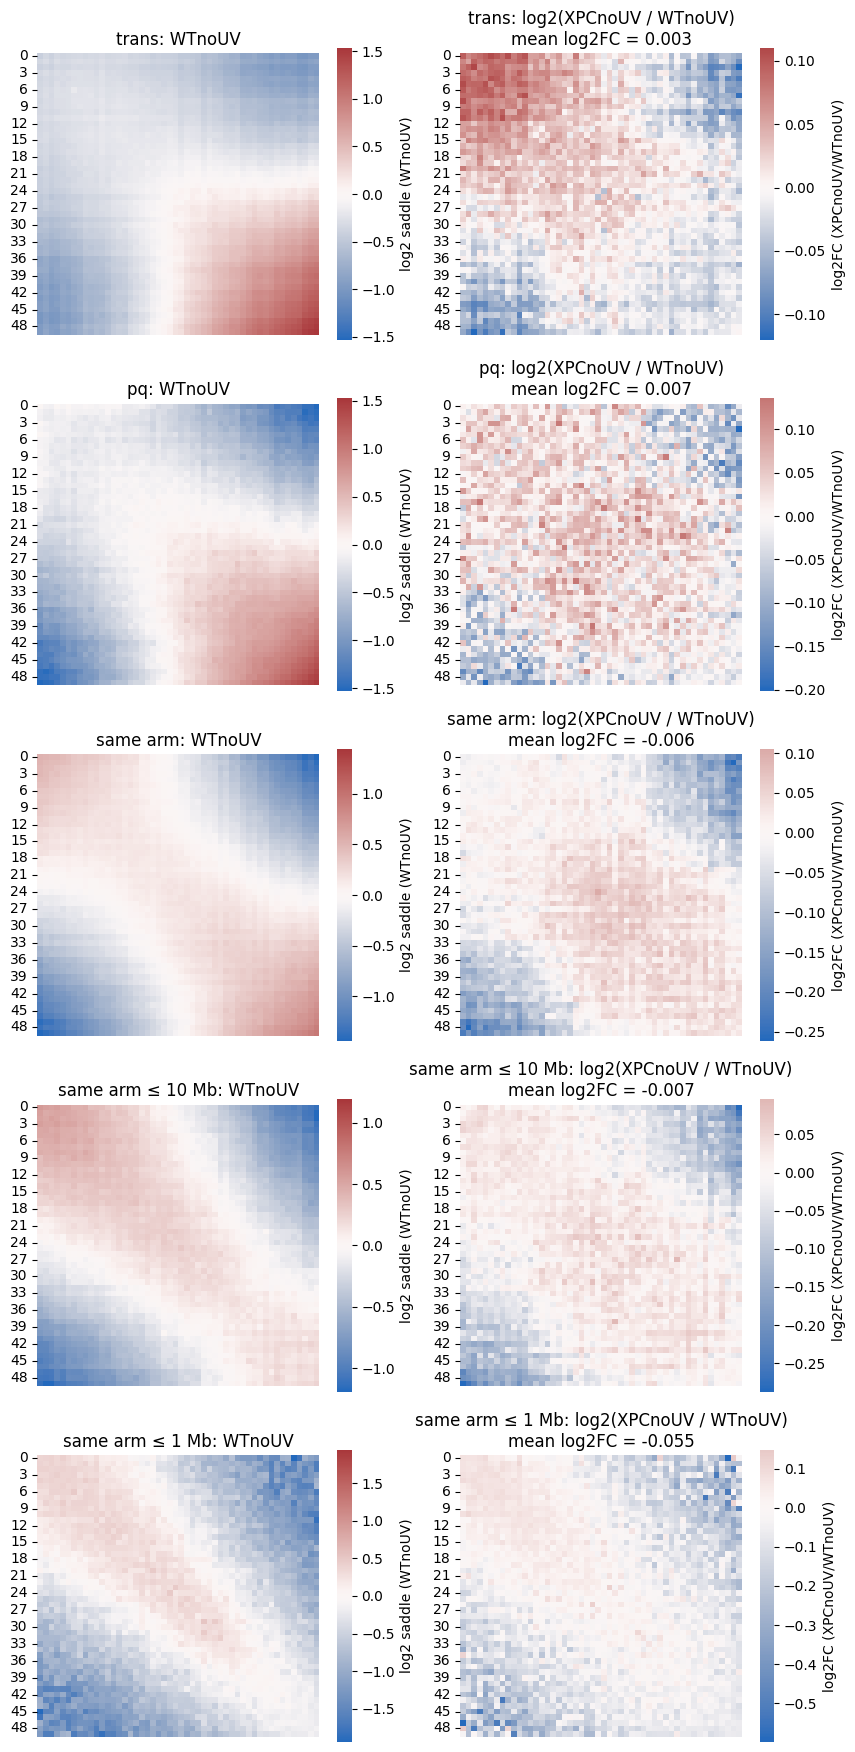

In [6]:
import os
os.makedirs(save_dir, exist_ok=True)

for comparison in comparisons:
    fig, axs = plot_saddle_comparison_5x2(
        comparison=comparison,
        trans_saddles=trans_saddles_viz,
        pq_saddles=pq_saddles_viz,
        same_arm_saddles=same_arm_saddles_viz,
        same_arm_saddles_upper_bounded_large=same_arm_saddles_upper_bounded_large_viz,
        same_arm_saddles_upper_bounded_small=same_arm_saddles_upper_bounded_small_viz,
        upper_bound_large=max_diag_large * resolution,
        upper_bound_small=max_diag_small * resolution,
        symmetric_left=True,
        symmetric_right=False
    )
    break

    s1, s2 = comparison
    fig.savefig(f"{save_dir}/saddle_comparison_{s1}_vs_{s2}_{track_name}.png", dpi=300)
    fig.savefig(f"{save_dir}/saddle_comparison_{s1}_vs_{s2}_{track_name}.svg")
    plt.close(fig)
    fig.clf()

### viz all saddles

In [7]:
clip_percentiles = (1, 99)

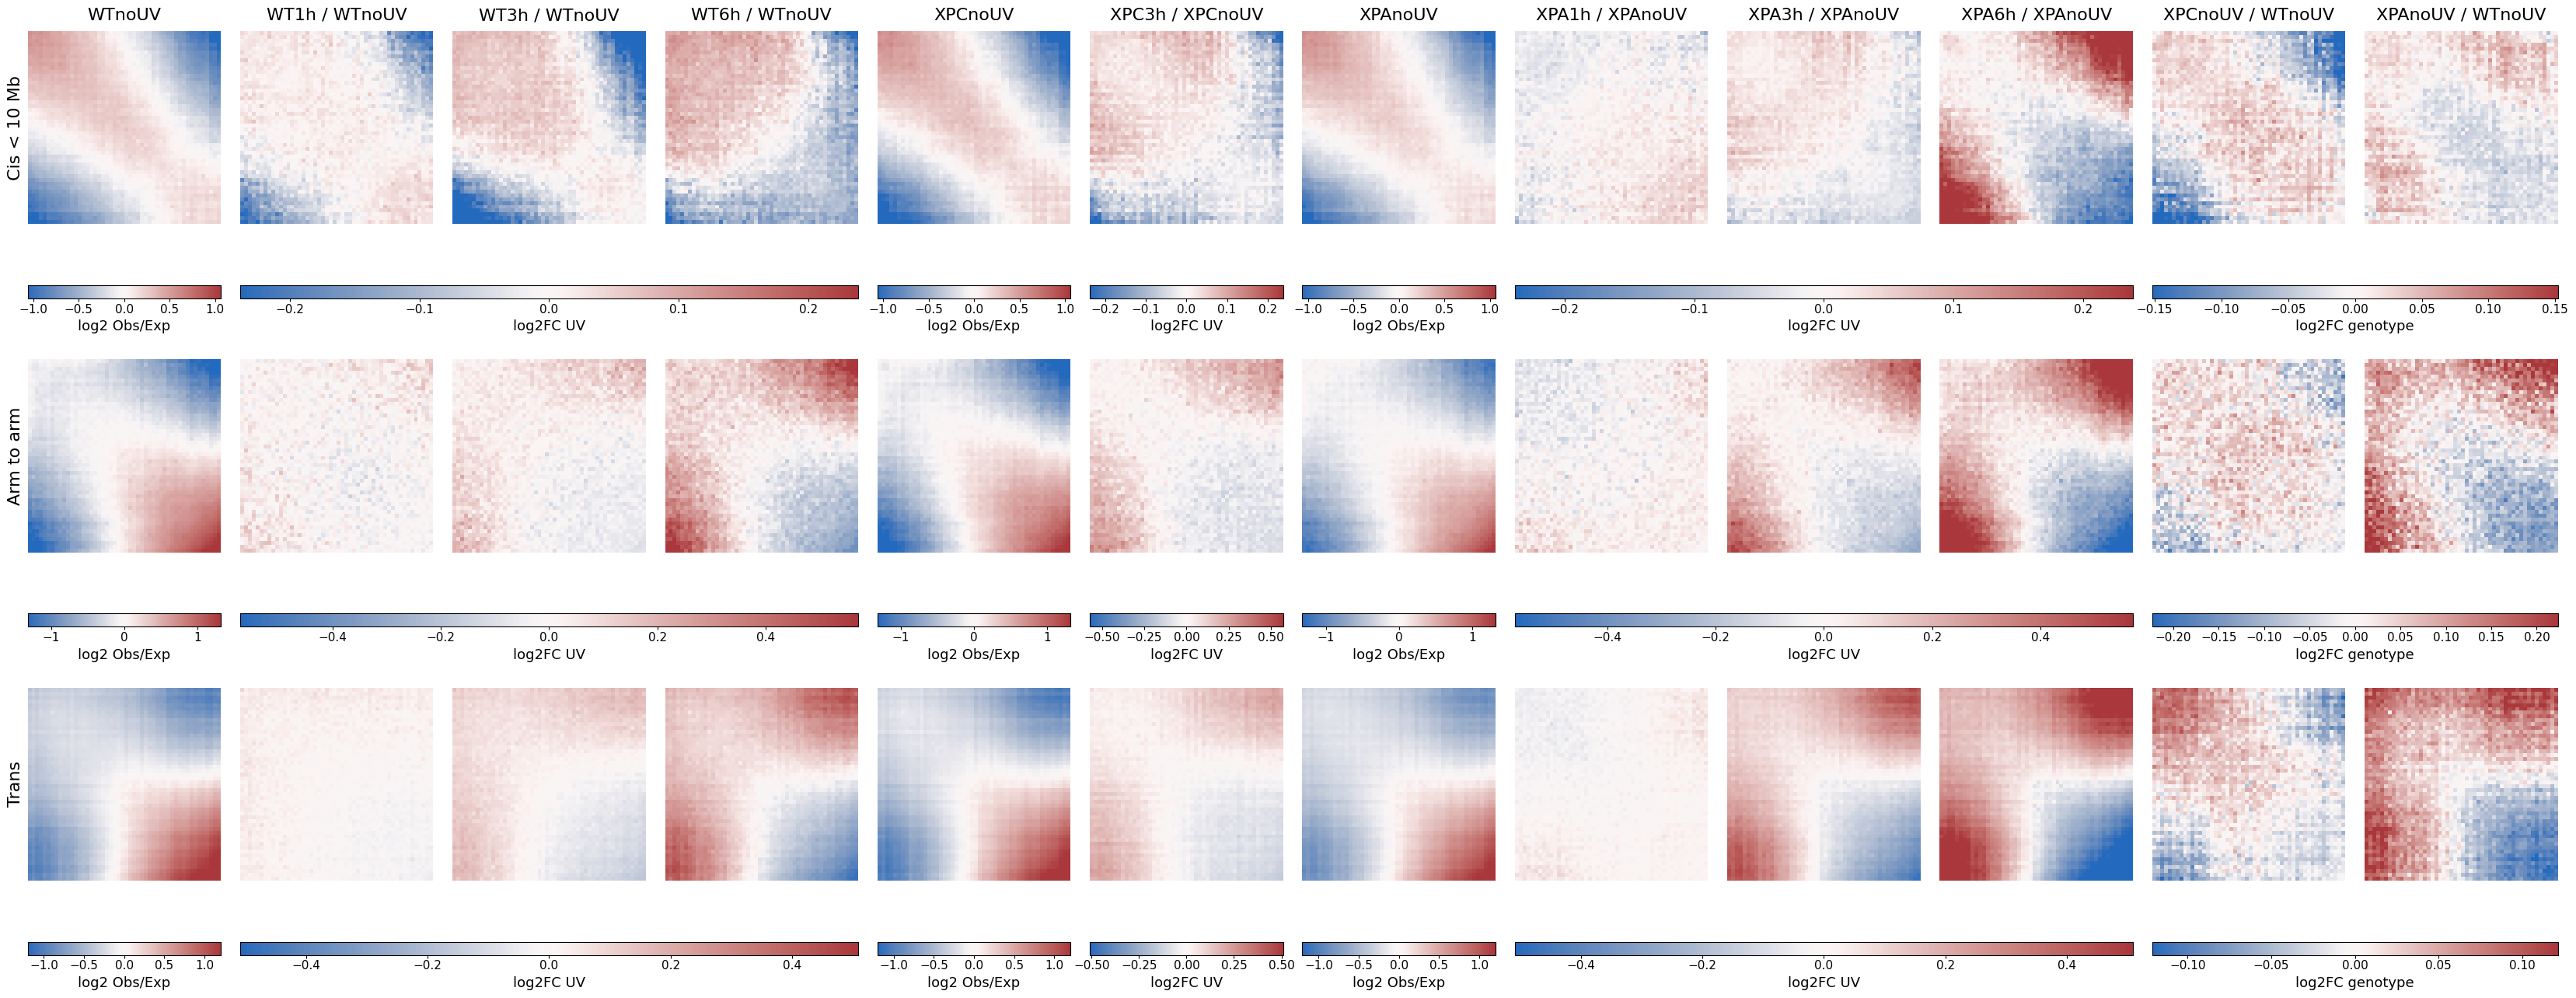

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ----------------------------
# styling
# ----------------------------
mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.titlesize": 18,
})

title_fs = 16
rowlabel_fs = 16
cbar_label_fs = 13
cbar_tick_fs = 11

# ----------------------------
# helpers
# ----------------------------
def _safe_log2(m):
    out = np.full_like(m, np.nan, dtype=float)
    valid = np.isfinite(m) & (m > 0)
    out[valid] = np.log2(m[valid])
    return out

def _safe_log2fc(base, comp):
    out = np.full_like(base, np.nan, dtype=float)
    valid = np.isfinite(base) & np.isfinite(comp) & (base > 0) & (comp > 0)
    out[valid] = np.log2(comp[valid] / base[valid])
    return out

def _sym_lim_percentile(mats, percentiles=(1, 99), fallback=1.0):
    vals = []
    for m in mats:
        v = m[np.isfinite(m)]
        if v.size:
            vals.append(v.ravel())

    if not vals:
        return -fallback, fallback

    vals = np.concatenate(vals)
    p_low, p_high = np.nanpercentile(vals, percentiles)
    vmax = max(abs(p_low), abs(p_high))

    if not np.isfinite(vmax) or vmax == 0:
        vmax = fallback

    return -vmax, vmax

# ----------------------------
# config
# ----------------------------

row_specs = [
    ("Cis < 10 Mb", same_arm_saddles_upper_bounded_large_viz),
    ("Arm to arm", pq_saddles_viz),
    ("Trans", trans_saddles_viz),
]

# Assumption:
# the repeated "XPCnoUV" in the original requested column order
# was a typo and should be "XPAnoUV" for the third baseline block.
col_specs = [
    ("WTnoUV", ("base", "WTnoUV")),
    ("WT1h / WTnoUV", ("uv_fc", "WTnoUV", "WT1h")),
    ("WT3h / WTnoUV", ("uv_fc", "WTnoUV", "WT3h")),
    ("WT6h / WTnoUV", ("uv_fc", "WTnoUV", "WT6h")),
    ("XPCnoUV", ("base", "XPCnoUV")),
    ("XPC3h / XPCnoUV", ("uv_fc", "XPCnoUV", "XPC3h")),
    ("XPAnoUV", ("base", "XPAnoUV")),
    ("XPA1h / XPAnoUV", ("uv_fc", "XPAnoUV", "XPA1h")),
    ("XPA3h / XPAnoUV", ("uv_fc", "XPAnoUV", "XPA3h")),
    ("XPA6h / XPAnoUV", ("uv_fc", "XPAnoUV", "XPA6h")),
    ("XPCnoUV / WTnoUV", ("geno_fc", "WTnoUV", "XPCnoUV")),
    ("XPAnoUV / WTnoUV", ("geno_fc", "WTnoUV", "XPAnoUV")),
]

# each subgroup gets its own local cbar axis under the same row
cbar_groups = [
    {"cols": [0],       "kind": "base",    "label": "log2 Obs/Exp"},
    {"cols": [1, 2, 3], "kind": "uv_fc",   "label": "log2FC UV"},
    {"cols": [4],       "kind": "base",    "label": "log2 Obs/Exp"},
    {"cols": [5],       "kind": "uv_fc",   "label": "log2FC UV"},
    {"cols": [6],       "kind": "base",    "label": "log2 Obs/Exp"},
    {"cols": [7, 8, 9], "kind": "uv_fc",   "label": "log2FC UV"},
    {"cols": [10, 11],  "kind": "geno_fc", "label": "log2FC genotype"},
]

# ----------------------------
# figure / layout
# true 6-row layout:
# heatmaps row 1
# cbar row 1
# heatmaps row 2
# cbar row 2
# heatmaps row 3
# cbar row 3
# ----------------------------
fig = plt.figure(figsize=(42, 16))
gs = fig.add_gridspec(
    nrows=6,
    ncols=12,
    height_ratios=[1, 0.05, 1, 0.05, 1, 0.05],
    hspace=0.20,
    wspace=0.10,
)

heat_axes = np.empty((3, 12), dtype=object)
cbar_axes = {}

for i in range(3):
    heat_r = 2 * i
    for j in range(12):
        heat_axes[i, j] = fig.add_subplot(gs[heat_r, j])

for i in range(3):
    cbar_r = 2 * i + 1
    cbar_axes[i] = {}
    for g, grp in enumerate(cbar_groups):
        c0, c1 = grp["cols"][0], grp["cols"][-1]
        cbar_axes[i][g] = fig.add_subplot(gs[cbar_r, c0:c1+1])

# ----------------------------
# compute per-row subgroup norms
# ----------------------------
row_norms = []

for i, (row_name, saddle_dict) in enumerate(row_specs):
    base_mats = [
        _safe_log2(saddle_dict[spec[1]])
        for _, spec in col_specs
        if spec[0] == "base"
    ]
    uv_fc_mats = [
        _safe_log2fc(saddle_dict[spec[1]], saddle_dict[spec[2]])
        for _, spec in col_specs
        if spec[0] == "uv_fc"
    ]
    geno_fc_mats = [
        _safe_log2fc(saddle_dict[spec[1]], saddle_dict[spec[2]])
        for _, spec in col_specs
        if spec[0] == "geno_fc"
    ]

    base_vmin, base_vmax = _sym_lim_percentile(base_mats, percentiles=clip_percentiles)
    uv_vmin, uv_vmax = _sym_lim_percentile(uv_fc_mats, percentiles=clip_percentiles)
    geno_vmin, geno_vmax = _sym_lim_percentile(geno_fc_mats, percentiles=clip_percentiles)

    row_norms.append({
        "base": mpl.colors.Normalize(vmin=base_vmin, vmax=base_vmax),
        "uv_fc": mpl.colors.Normalize(vmin=uv_vmin, vmax=uv_vmax),
        "geno_fc": mpl.colors.Normalize(vmin=geno_vmin, vmax=geno_vmax),
    })

    # ----------------------------
    # heatmaps
    # ----------------------------
    for j, (title, spec) in enumerate(col_specs):
        ax = heat_axes[i, j]
        kind = spec[0]

        if kind == "base":
            data = _safe_log2(saddle_dict[spec[1]])
            vmin, vmax = base_vmin, base_vmax
        elif kind == "uv_fc":
            data = _safe_log2fc(saddle_dict[spec[1]], saddle_dict[spec[2]])
            vmin, vmax = uv_vmin, uv_vmax
        elif kind == "geno_fc":
            data = _safe_log2fc(saddle_dict[spec[1]], saddle_dict[spec[2]])
            vmin, vmax = geno_vmin, geno_vmax
        else:
            raise ValueError(f"Unknown kind: {kind}")

        sns.heatmap(
            data,
            ax=ax,
            cmap="vlag",
            center=0,
            vmin=vmin,
            vmax=vmax,
            cbar=False,
            square=True,
            xticklabels=False,
            yticklabels=False,
        )

        if i == 0:
            ax.set_title(title, fontsize=title_fs, pad=10)

        if j == 0:
            ax.set_ylabel(row_name, fontsize=rowlabel_fs)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")

# ----------------------------
# local subgroup colorbars
# ----------------------------
for i in range(3):
    for g, grp in enumerate(cbar_groups):
        cax = cbar_axes[i][g]
        kind = grp["kind"]
        label = grp["label"]

        sm = mpl.cm.ScalarMappable(norm=row_norms[i][kind], cmap="vlag")
        sm.set_array([])

        cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
        cb.set_label(label, fontsize=cbar_label_fs, labelpad=4)
        cb.ax.tick_params(labelsize=cbar_tick_fs, length=3, pad=2)

plt.show()

# fig.savefig(f"{save_dir}/saddle_3x12_local_subgroup_cbars_gridspec_bigtext_{track_name}.png", dpi=300, bbox_inches="tight")
# fig.savefig(f"{save_dir}/saddle_3x12_local_subgroup_cbars_gridspec_bigtext_{track_name}.svg", bbox_inches="tight")

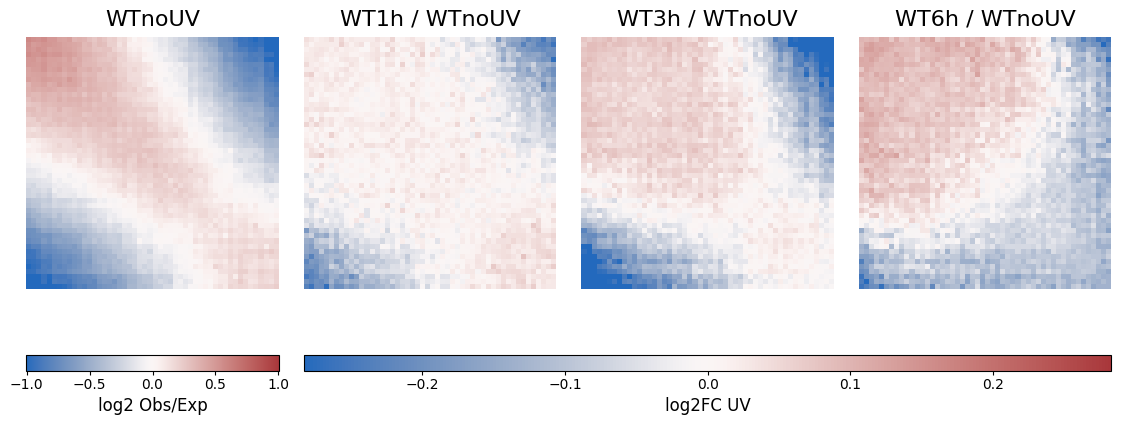

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ----------------------------
# styling
# ----------------------------
mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.titlesize": 18,
})

title_fs = 16
cbar_label_fs = 12
cbar_tick_fs = 10

# ----------------------------
# helpers
# ----------------------------
def _safe_log2(m):
    out = np.full_like(m, np.nan, dtype=float)
    valid = np.isfinite(m) & (m > 0)
    out[valid] = np.log2(m[valid])
    return out

def _safe_log2fc(base, comp):
    out = np.full_like(base, np.nan, dtype=float)
    valid = np.isfinite(base) & np.isfinite(comp) & (base > 0) & (comp > 0)
    out[valid] = np.log2(comp[valid] / base[valid])
    return out

def _sym_lim_percentile(mats, percentiles=(1, 99), fallback=1.0):
    vals = []
    for m in mats:
        v = m[np.isfinite(m)]
        if v.size:
            vals.append(v.ravel())

    if not vals:
        return -fallback, fallback

    vals = np.concatenate(vals)
    p_low, p_high = np.nanpercentile(vals, percentiles)
    vmax = max(abs(p_low), abs(p_high))

    if not np.isfinite(vmax) or vmax == 0:
        vmax = fallback

    return -vmax, vmax

# ----------------------------
# config
# ----------------------------
saddle_dict = same_arm_saddles_upper_bounded_large_viz  # Cis < 10 Mb

col_specs = [
    ("WTnoUV", ("base", "WTnoUV")),
    ("WT1h / WTnoUV", ("uv_fc", "WTnoUV", "WT1h")),
    ("WT3h / WTnoUV", ("uv_fc", "WTnoUV", "WT3h")),
    ("WT6h / WTnoUV", ("uv_fc", "WTnoUV", "WT6h")),
]

# shared scales within this 1x4 panel
base_mats = [
    _safe_log2(saddle_dict[spec[1]])
    for _, spec in col_specs if spec[0] == "base"
]
uv_fc_mats = [
    _safe_log2fc(saddle_dict[spec[1]], saddle_dict[spec[2]])
    for _, spec in col_specs if spec[0] == "uv_fc"
]

base_vmin, base_vmax = _sym_lim_percentile(base_mats, percentiles=clip_percentiles)
uv_vmin, uv_vmax = _sym_lim_percentile(uv_fc_mats, percentiles=clip_percentiles)

# ----------------------------
# layout
# ----------------------------
fig = plt.figure(figsize=(14, 4.8))
gs = fig.add_gridspec(
    nrows=2,
    ncols=4,
    height_ratios=[1, 0.05],
    hspace=0.18,
    wspace=0.10,
)

axs = [fig.add_subplot(gs[0, j]) for j in range(4)]
cax_base = fig.add_subplot(gs[1, 0])
cax_uv = fig.add_subplot(gs[1, 1:4])

# ----------------------------
# heatmaps
# ----------------------------
for j, (title, spec) in enumerate(col_specs):
    ax = axs[j]
    kind = spec[0]

    if kind == "base":
        data = _safe_log2(saddle_dict[spec[1]])
        vmin, vmax = base_vmin, base_vmax
    elif kind == "uv_fc":
        data = _safe_log2fc(saddle_dict[spec[1]], saddle_dict[spec[2]])
        vmin, vmax = uv_vmin, uv_vmax
    else:
        raise ValueError(f"Unknown kind: {kind}")

    sns.heatmap(
        data,
        ax=ax,
        cmap="vlag",
        center=0,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        square=True,
        xticklabels=False,
        yticklabels=False,
    )

    ax.set_title(title, fontsize=title_fs, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")

# ----------------------------
# colorbars
# ----------------------------
sm_base = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=base_vmin, vmax=base_vmax),
    cmap="vlag",
)
sm_base.set_array([])

cb_base = fig.colorbar(sm_base, cax=cax_base, orientation="horizontal")
cb_base.set_label("log2 Obs/Exp", fontsize=cbar_label_fs, labelpad=3)
cb_base.ax.tick_params(labelsize=cbar_tick_fs, length=3, pad=2)

sm_uv = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=uv_vmin, vmax=uv_vmax),
    cmap="vlag",
)
sm_uv.set_array([])

cb_uv = fig.colorbar(sm_uv, cax=cax_uv, orientation="horizontal")
cb_uv.set_label("log2FC UV", fontsize=cbar_label_fs, labelpad=3)
cb_uv.ax.tick_params(labelsize=cbar_tick_fs, length=3, pad=2)

plt.show()

# fig.savefig(f"{save_dir}/cis_lt10mb_WTnoUV_WT1h_WT3h_WT6h_{track_name}.png", dpi=300, bbox_inches="tight")
# fig.savefig(f"{save_dir}/cis_lt10mb_WTnoUV_WT1h_WT3h_WT6h_{track_name}.svg", bbox_inches="tight")

### comp strength <10mb

In [10]:
from cooltools.api.saddle import saddle_strength
from ggner_3d import plotting
plotting.update_rcparams()
x = np.arange(n_bins)

COLORS = plotting.COLORS
COLORS += [
    '#8A6E59'
]

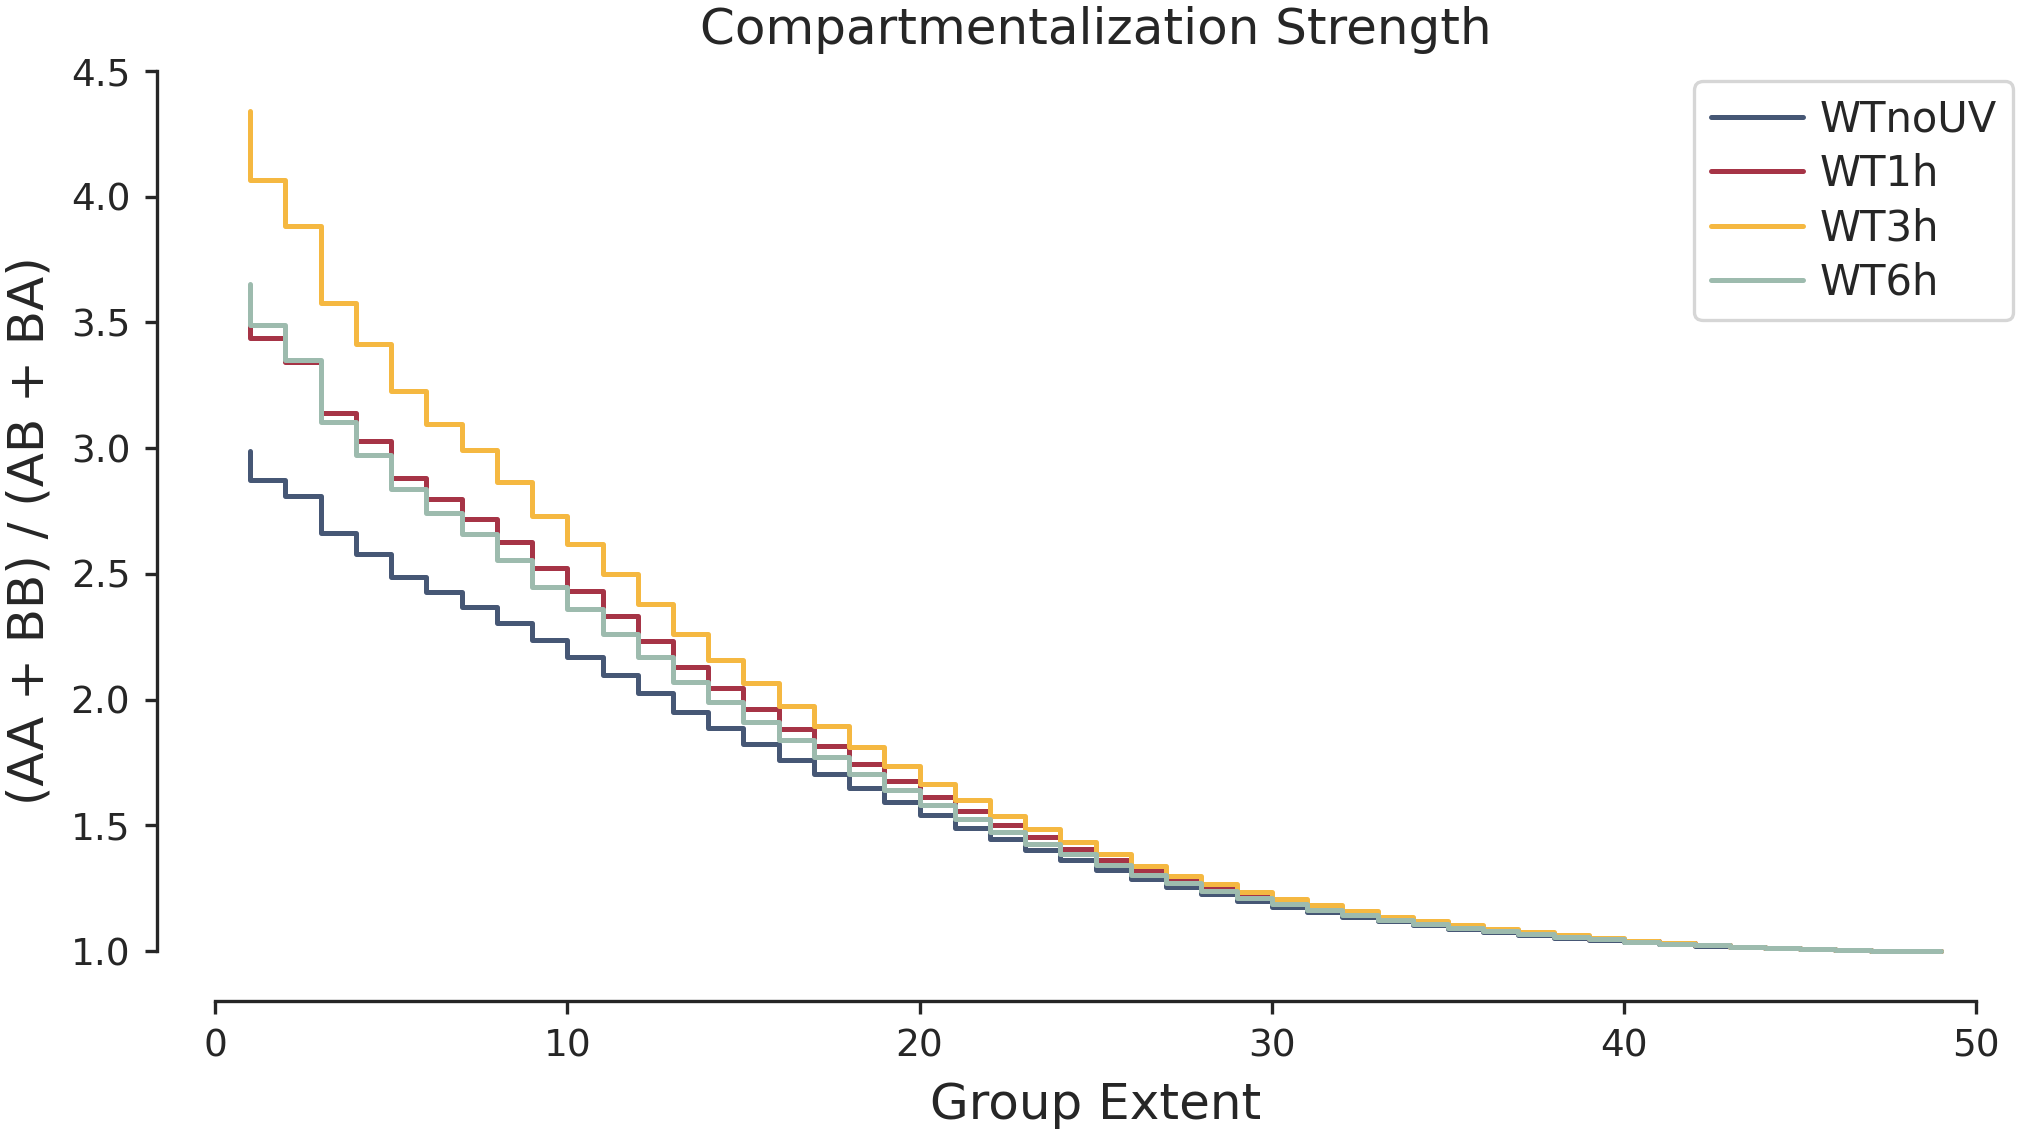

In [11]:
WT_keys = ['WTnoUV', 'WT1h', 'WT3h', 'WT6h']

color_map = {
    'WTnoUV': COLORS[0],
    'WT1h': COLORS[1],
    'WT3h': COLORS[2],
    'WT6h': COLORS[3],
}

fig, ax = plt.subplots(figsize=(8, 4))

for i, k in enumerate(WT_keys):
    interaction_sum, interaction_count = same_arm_saddles_upper_bounded_large[k]
    sd = saddle_strength(interaction_sum, interaction_count)
    ax.step(x[1:], sd[1:], where='pre', label=k, color=color_map[k])

ax.set_xlabel("Group Extent")
ax.set_ylabel("(AA + BB) / (AB + BA)")
ax.set_title("Compartmentalization Strength")

plt.legend(title="", fontsize=10)

plotting.despine(ax)

fig.savefig(f"{save_dir}/compartment_strength_wtUV_cis_lt10mb_{track_name}.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{save_dir}/compartment_strength_wtUV_cis_lt10mb_{track_name}.svg", bbox_inches="tight")

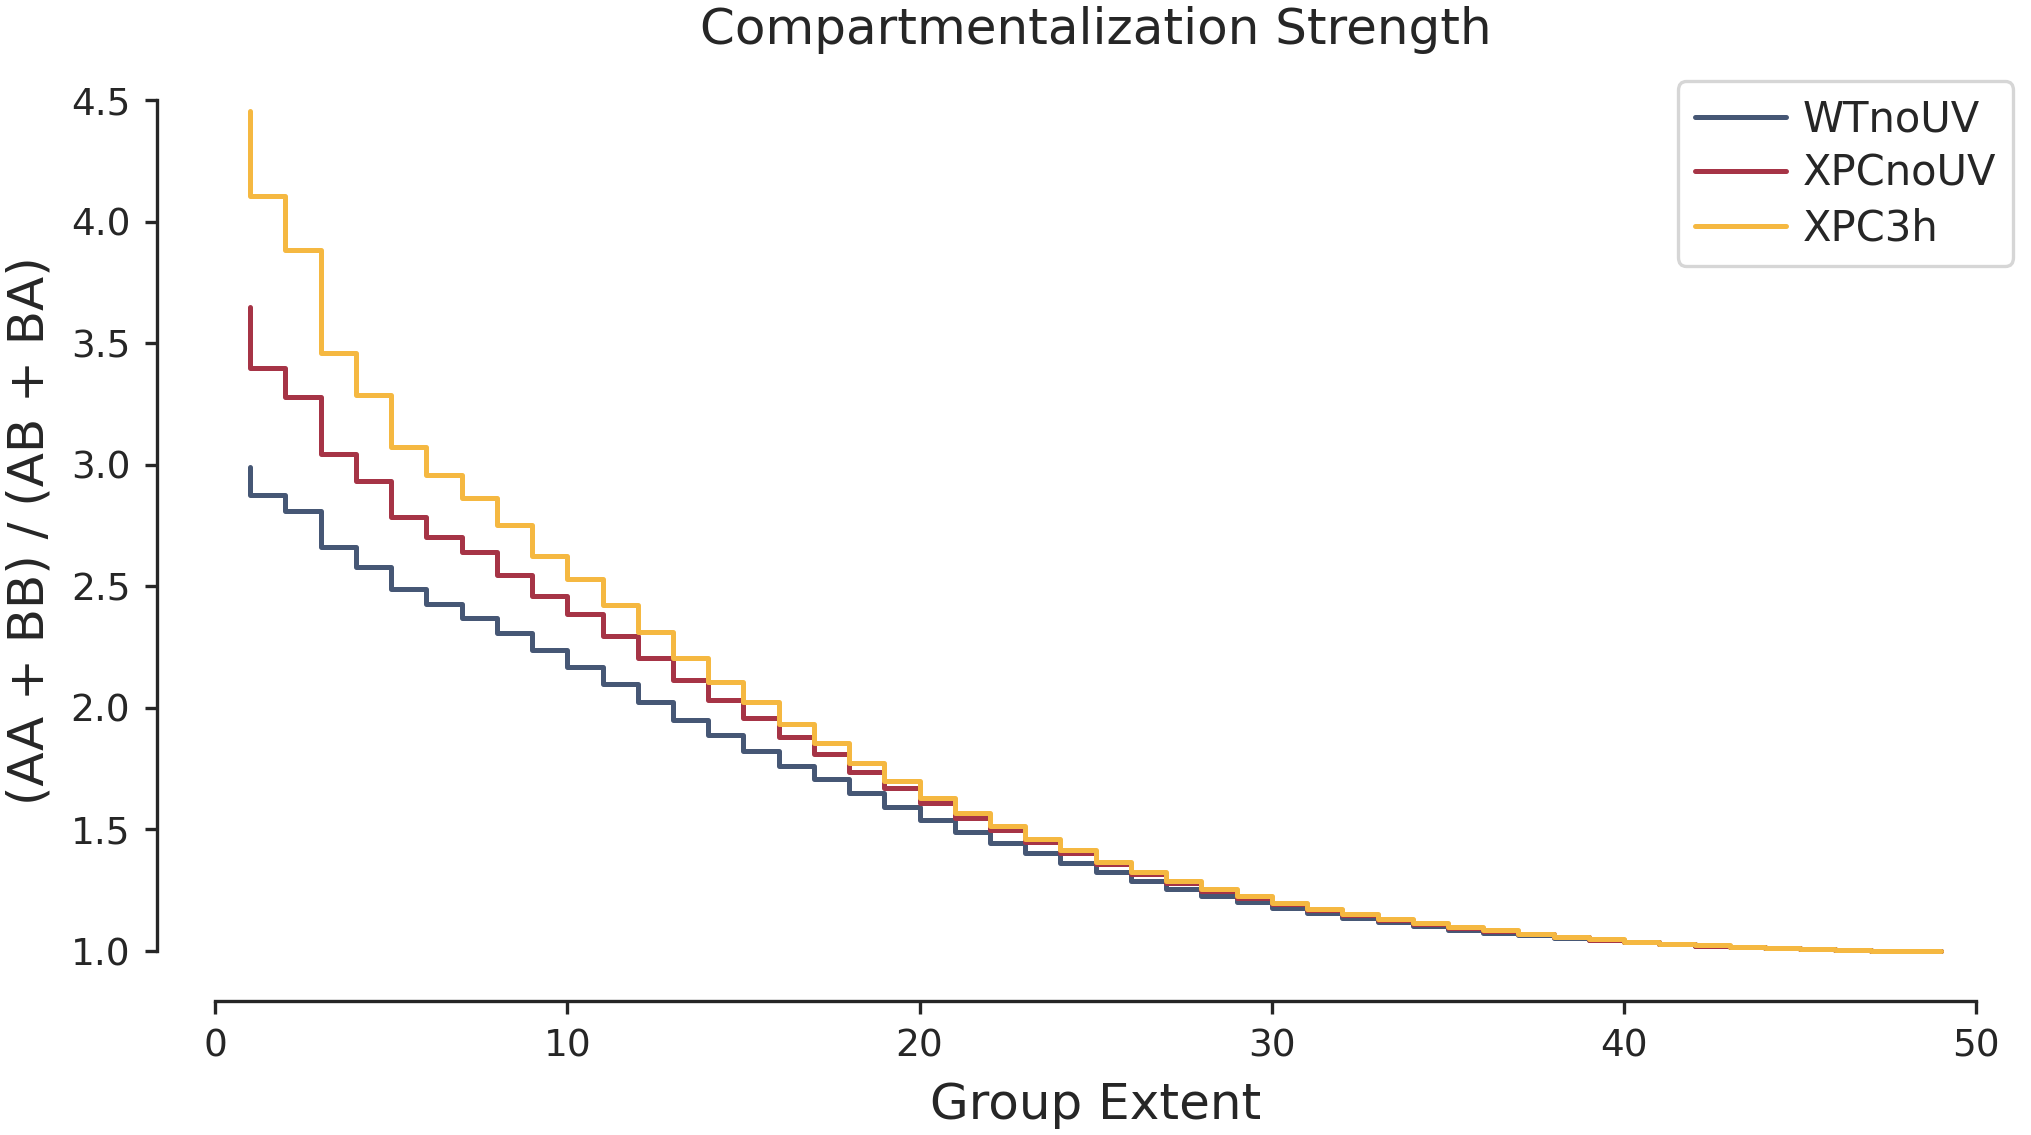

In [12]:
XPC_keys = ['WTnoUV', 'XPCnoUV', 'XPC3h']

color_map = {
    'WTnoUV': COLORS[0],
    'XPCnoUV': COLORS[1],
    'XPC3h': COLORS[2],
}

fig, ax = plt.subplots(figsize=(8, 4))

for i, k in enumerate(XPC_keys):
    interaction_sum, interaction_count = same_arm_saddles_upper_bounded_large[k]
    sd = saddle_strength(interaction_sum, interaction_count)
    ax.step(x[1:], sd[1:], where='pre', label=k, color=color_map[k])

ax.set_xlabel("Group Extent")
ax.set_ylabel("(AA + BB) / (AB + BA)")
ax.set_title("Compartmentalization Strength")

plt.legend(title="", fontsize=10)

plotting.despine(ax)

fig.savefig(f"{save_dir}/compartment_strength_xpcUV_cis_lt10mb_{track_name}.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{save_dir}/compartment_strength_xpcUV_cis_lt10mb_{track_name}.svg", bbox_inches="tight")

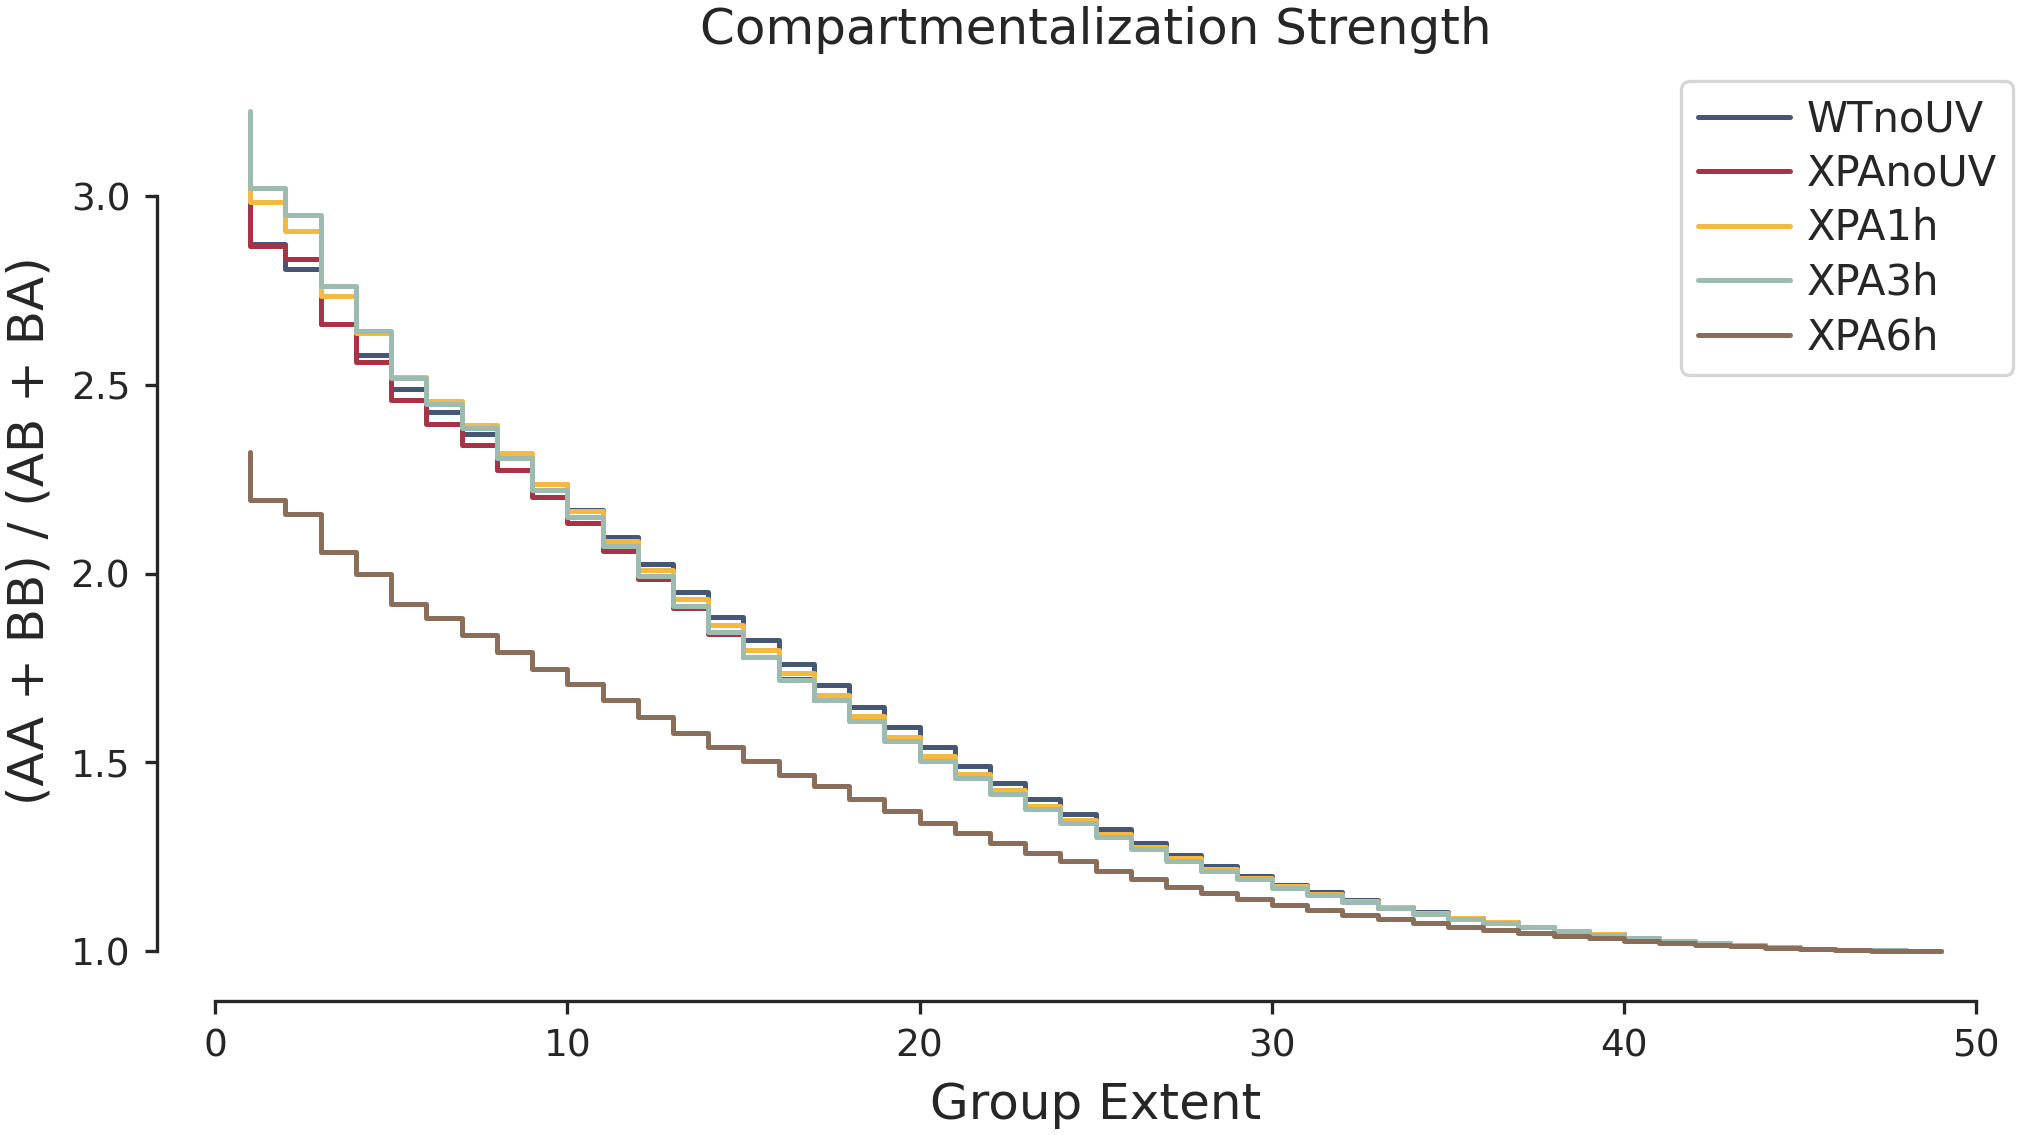

In [13]:
XPA_keys = ['WTnoUV', 'XPAnoUV', 'XPA1h', 'XPA3h', 'XPA6h']

color_map = {
    'WTnoUV': COLORS[0],
    'XPAnoUV': COLORS[1],
    'XPA1h': COLORS[2],
    'XPA3h': COLORS[3],
    'XPA6h': COLORS[4],
}

fig, ax = plt.subplots(figsize=(8, 4))

for i, k in enumerate(XPA_keys):
    interaction_sum, interaction_count = same_arm_saddles_upper_bounded_large[k]
    sd = saddle_strength(interaction_sum, interaction_count)
    ax.step(x[1:], sd[1:], where='pre', label=k, color=color_map[k])

ax.set_xlabel("Group Extent")
ax.set_ylabel("(AA + BB) / (AB + BA)")
ax.set_title("Compartmentalization Strength")

plt.legend(title="", fontsize=10)

plotting.despine(ax)

fig.savefig(f"{save_dir}/compartment_strength_xpaUV_cis_lt10mb_{track_name}.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{save_dir}/compartment_strength_xpaUV_cis_lt10mb_{track_name}.svg", bbox_inches="tight")

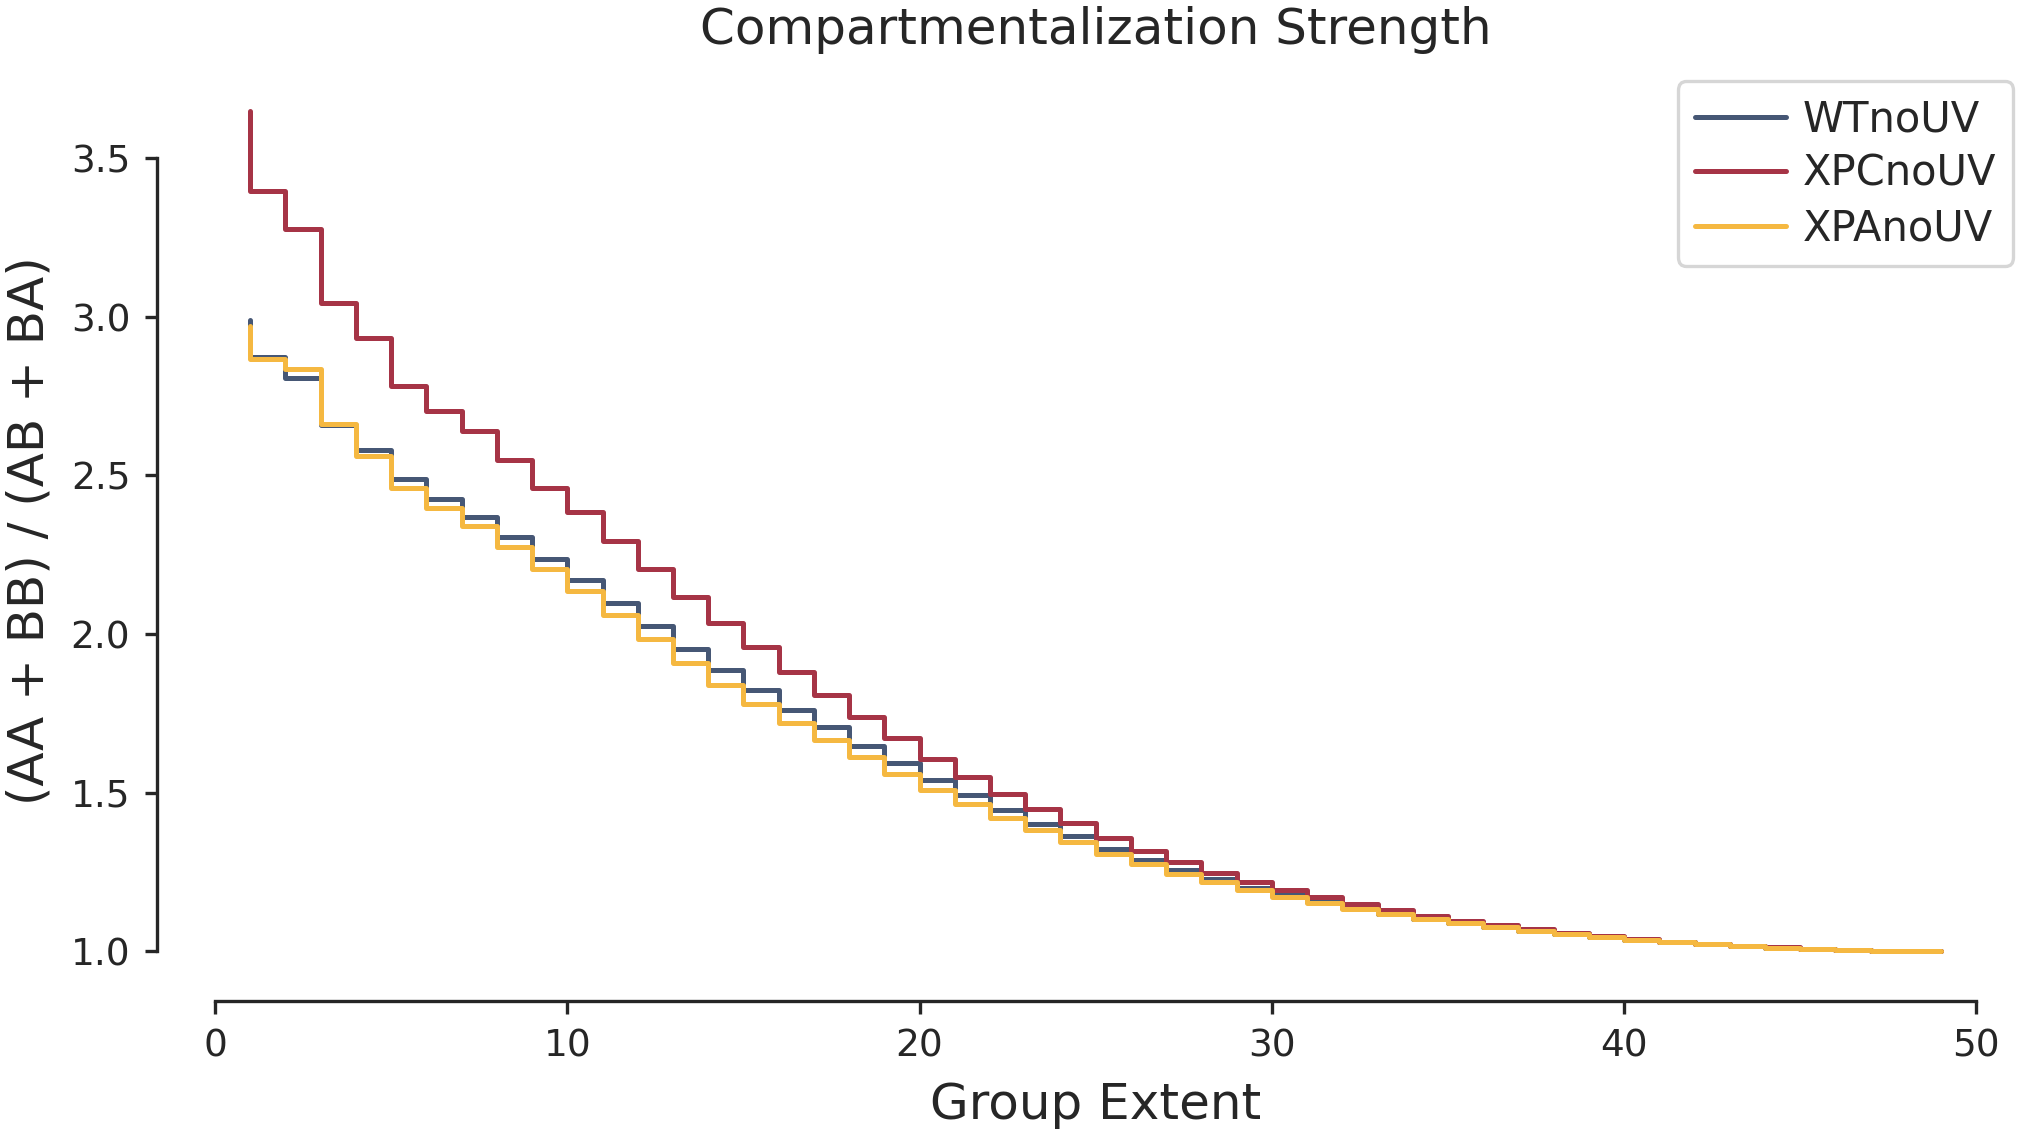

In [14]:
XPA_keys = ['WTnoUV', 'XPCnoUV', 'XPAnoUV']

color_map = {
    'WTnoUV': COLORS[0],
    'XPCnoUV': COLORS[1],
    'XPAnoUV': COLORS[2],
}

fig, ax = plt.subplots(figsize=(8, 4))

for i, k in enumerate(XPA_keys):
    interaction_sum, interaction_count = same_arm_saddles_upper_bounded_large[k]
    sd = saddle_strength(interaction_sum, interaction_count)
    ax.step(x[1:], sd[1:], where='pre', label=k, color=color_map[k])

ax.set_xlabel("Group Extent")
ax.set_ylabel("(AA + BB) / (AB + BA)")
ax.set_title("Compartmentalization Strength")

plt.legend(title="", fontsize=10)

plotting.despine(ax)

fig.savefig(f"{save_dir}/compartment_strength_genotype_cis_lt10mb_{track_name}.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{save_dir}/compartment_strength_genotype_cis_lt10mb_{track_name}.svg", bbox_inches="tight")